# Прогноз активности пользователей на август 2026 года

## tl;dr

- **Основная метрика:** дневной DAU ленты — число уникальных пользователей, совершивших хотя бы одно действие за день.
- **Разрешение:** день. Оно связано с задачей планирования нагрузки и позволяет учесть недельную сезонность.
- **Валидация:** данных только 63 полных дня. Для полноценного 31-дневного rolling backtest их недостаточно, поэтому модели сравниваются на четырёх 7-дневных окнах.
- **Лучшая модель:** Orbit LGT с недельной сезонностью и индикатором флэшмоба. На бэктесте средний `MAE ≈ 747 DAU`, `WAPE ≈ 4.7%`.
- **Прогноз августа:** в среднем около **25 тыс. DAU в день**, рост от примерно **20.3 тыс.** в начале до **29.6 тыс.** в конце месяца. Интервал неопределённости существенно расширяется, поэтому прогноз нельзя напрямую считать расчётом серверной мощности.

Датасет — обезличенная учебная дневная витрина Karpov.Courses из таблицы `simulator_20260720.feed_actions`.

## Context & Methods

### Бизнес-задача

Команда получает жалобы на подвисания приложения и хочет понять, как изменится активность пользователей в ближайшем календарном месяце. Прогноз нужен как вход для capacity planning.

### Почему DAU

DAU устойчивее отдельных событий и хорошо объясним бизнесу: больше уникальных активных пользователей обычно означает больше параллельных сессий и запросов. При этом DAU — **прокси нагрузки**, а не сама нагрузка. Для точного планирования инфраструктуры дополнительно нужны RPS, p95/p99 latency, CPU, memory и число действий на пользователя.

### Разрешение и компоненты

- дневное разрешение — достаточно детально для недельного паттерна и не так шумно, как часы;
- недельная сезонность (`seasonality=7`) задаётся внутри Orbit LGT;
- индикатор известного флэшмоба 10–16 июля включён как календарный регрессор, а для будущего равен нулю;
- `views`, `likes` и `CTR` не включаются: их будущие значения неизвестны, а использование факта создало бы утечку.

### План проверки

Сравниваем сезонный naive, линейный trend+week, Holt–Winters и Orbit LGT на одинаковых последовательных 7-дневных тестах. Метрики: MAE, RMSE и WAPE.

In [1]:
import logging
import warnings
from pathlib import Path

warnings.filterwarnings("ignore")
logging.getLogger("orbit").setLevel(logging.ERROR)

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from orbit.models import LGT
from sklearn.linear_model import Ridge
from statsmodels.tsa.holtwinters import ExponentialSmoothing

plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")
SEED = 42

cwd = Path.cwd()
candidates = [
    cwd / "data" / "daily_activity_metrics.csv",
    cwd / "data" / "flashmob_daily_metrics.csv",
    cwd.parent / "data" / "daily_activity_metrics.csv",
    cwd.parent / "data" / "flashmob_daily_metrics.csv",
]
DATA_PATH = next((path for path in candidates if path.exists()), None)
if DATA_PATH is None:
    raise FileNotFoundError("Не найдена дневная витрина в папке data")

## Data

Витрина строится из событий ленты следующим запросом (пароль в ноутбук не записывается):

```sql
SELECT
    toDate(time) AS date,
    uniqExact(user_id) AS dau,
    countIf(action = 'like') AS likes,
    countIf(action = 'view') AS views,
    likes / nullIf(views, 0) AS ctr,
    uniqExactIf(post_id, action = 'view') AS unique_viewed_posts
FROM simulator_20260720.feed_actions
WHERE time < toDateTime('2026-08-01 00:00:00')
GROUP BY date
ORDER BY date;
```

Граница `< 2026-08-01` исключает неполный текущий день. Одна строка соответствует одному календарному дню.

In [2]:
daily = pd.read_csv(DATA_PATH, parse_dates=["date"]).sort_values("date")
daily = daily[["date", "dau", "likes", "views", "ctr", "unique_viewed_posts", "new_posts"]]
daily["is_flashmob"] = daily["date"].between("2026-07-10", "2026-07-16").astype(int)

expected_dates = pd.date_range(daily["date"].min(), daily["date"].max(), freq="D")
quality = pd.Series({
    "первая дата": daily["date"].min().date(),
    "последняя полная дата": daily["date"].max().date(),
    "дней": len(daily),
    "дубликатов дат": int(daily["date"].duplicated().sum()),
    "пропущенных дней": len(expected_dates.difference(daily["date"])),
    "пропусков": int(daily.isna().sum().sum()),
    "минимальный DAU": int(daily["dau"].min()),
    "максимальный DAU": int(daily["dau"].max()),
})

assert quality["дубликатов дат"] == 0
assert quality["пропущенных дней"] == 0
assert quality["пропусков"] == 0
assert (daily["dau"] > 0).all()
assert np.allclose(daily["ctr"], daily["likes"] / daily["views"])
display(quality.to_frame("значение"))
display(daily.head())

,значение
первая дата,2026-05-30
последняя полная дата,2026-07-31
дней,63
дубликатов дат,0
пропущенных дней,0
пропусков,0
минимальный DAU,878
максимальный DAU,20400


,date,dau,likes,views,ctr,unique_viewed_posts,new_posts,is_flashmob
0,2026-05-30,878,1560,7603,0.21,89,89,0
1,2026-05-31,2238,12816,62770,0.20,178,97,0
2,2026-06-01,3105,20958,105526,0.20,191,61,0
3,2026-06-02,3721,23800,118996,0.20,211,87,0
4,2026-06-03,4617,34504,174454,0.20,214,70,0


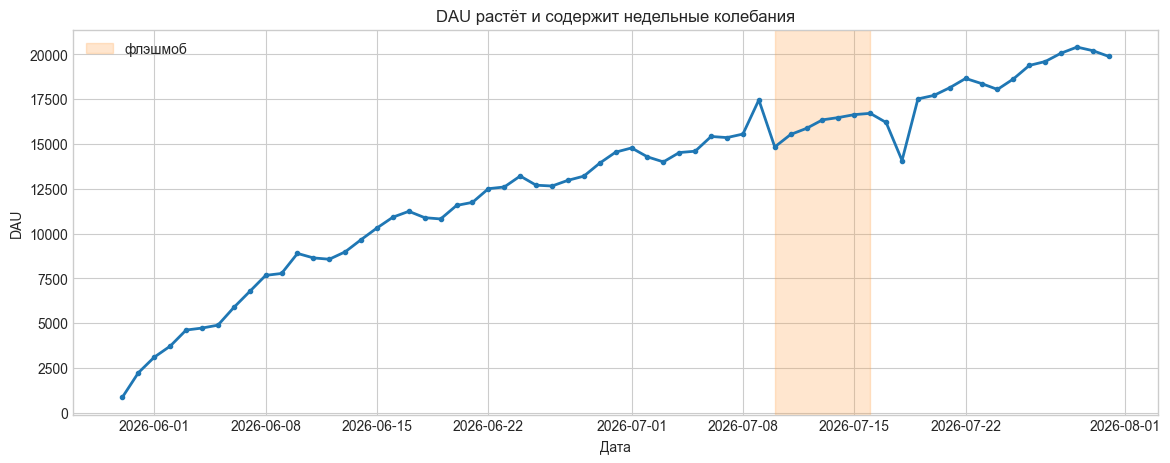

,weekday,dau
0,Friday,"13,317.56"
1,Monday,"12,951.67"
2,Saturday,"11,445.56"
3,Sunday,"12,328.33"
4,Thursday,"13,771.67"
5,Tuesday,"13,284.56"
6,Wednesday,"13,773.33"


In [3]:
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(daily["date"], daily["dau"], marker="o", markersize=3, linewidth=2)
ax.axvspan(pd.Timestamp("2026-07-10"), pd.Timestamp("2026-07-16"),
           color="#ff9f43", alpha=0.25, label="флэшмоб")
ax.set(title="DAU растёт и содержит недельные колебания", xlabel="Дата", ylabel="DAU")
ax.legend()
plt.show()

weekday_profile = (
    daily.assign(weekday=daily["date"].dt.day_name())
    .groupby("weekday", as_index=False)["dau"].mean()
)
weekday_profile

### Хватает ли данных для месячного бэктеста?

Нет. Для одного календарного месяца нужен горизонт 31 день. При 63 наблюдениях один такой holdout оставляет лишь 32 дня на обучение и даёт только одну оценку ошибки. Это недостаточно, чтобы проверить устойчивость модели на разных точках старта.

Для 7-дневного горизонта после минимальных четырёх недель обучения доступны несколько независимых окон. Поэтому выбор модели валидируем на неделе, а финальный прогноз на август помечаем как более рискованную экстраполяцию.

In [4]:
TARGET_HORIZON = 31
VALIDATION_HORIZON = 7
MIN_TRAIN_DAYS = 28

horizon_check = pd.Series({
    "наблюдений": len(daily),
    "горизонт задания, дней": TARGET_HORIZON,
    "обучающих дней при одном holdout": len(daily) - TARGET_HORIZON,
    "максимум непересекающихся месячных holdout после 28 дней обучения":
        (len(daily) - MIN_TRAIN_DAYS) // TARGET_HORIZON,
    "максимум недельных holdout после 28 дней обучения":
        (len(daily) - MIN_TRAIN_DAYS) // VALIDATION_HORIZON,
})
horizon_check.to_frame("значение")

,значение
наблюдений,63
"горизонт задания, дней",31
обучающих дней при одном holdout,32
максимум непересекающихся месячных holdout после 28 дней обучения,1
максимум недельных holdout после 28 дней обучения,5


## Results

### Rolling backtest

Тестовые недели не пересекаются с флэшмобом. Для каждой точки старта модель обучается только на данных, которые были бы доступны в тот момент.

In [5]:
def score(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    error = y_true - y_pred
    return {
        "MAE": np.mean(np.abs(error)),
        "RMSE": np.sqrt(np.mean(error ** 2)),
        "WAPE, %": np.sum(np.abs(error)) / np.sum(np.abs(y_true)) * 100,
    }


def design_matrix(frame, first_date):
    t = (frame["date"] - first_date).dt.days.to_numpy()
    return np.column_stack([
        t,
        np.sin(2 * np.pi * t / 7),
        np.cos(2 * np.pi * t / 7),
        frame["is_flashmob"].to_numpy(),
    ])


def seasonal_naive(train, test):
    lookup = train.set_index("date")["dau"]
    return lookup.reindex(test["date"] - pd.Timedelta(days=7)).to_numpy()


def ridge_forecast(train, test):
    first_date = daily["date"].min()
    model = Ridge(alpha=1.0)
    model.fit(design_matrix(train, first_date), train["dau"])
    return model.predict(design_matrix(test, first_date))


def holt_winters_forecast(train, test):
    model = ExponentialSmoothing(
        train["dau"], trend="add", damped_trend=True,
        seasonal="add", seasonal_periods=7,
        initialization_method="estimated",
    ).fit(optimized=True)
    return model.forecast(len(test)).to_numpy()


def orbit_forecast(train, test, steps=201, samples=100):
    model = LGT(
        response_col="dau",
        date_col="date",
        seasonality=7,
        regressor_col=["is_flashmob"],
        estimator="pyro-svi",
        seed=SEED,
        num_steps=steps,
        num_sample=samples,
        message=10_000,
    )
    model.fit(train)
    return model, model.predict(test)


fold_starts = pd.to_datetime([
    "2026-06-27", "2026-07-04", "2026-07-18", "2026-07-25"
])
rows = []

for fold_start in fold_starts:
    train = daily[daily["date"] < fold_start].copy()
    test = daily[
        daily["date"].between(fold_start, fold_start + pd.Timedelta(days=6))
    ].copy()

    predictions = {
        "Seasonal naive": seasonal_naive(train, test),
        "Ridge trend+week": ridge_forecast(train, test),
        "Holt-Winters": holt_winters_forecast(train, test),
    }
    _, orbit_prediction = orbit_forecast(train, test)
    predictions["Orbit LGT"] = orbit_prediction["prediction"].to_numpy()

    for model_name, prediction in predictions.items():
        rows.append({
            "fold_start": fold_start.date(),
            "train_days": len(train),
            "model": model_name,
            **score(test["dau"], prediction),
        })

backtest = pd.DataFrame(rows)
backtest

2026-08-01 17:40:31 - orbit - INFO - Using SVI (Pyro) with steps: 201, samples: 100, learning rate: 0.1, learning_rate_total_decay: 1.0 and particles: 100.


2026-08-01 17:40:32 - orbit - INFO - step    0 loss = 341.8, scale = 0.11279


INFO:orbit:step    0 loss = 341.8, scale = 0.11279


2026-08-01 17:40:33 - orbit - INFO - Using SVI (Pyro) with steps: 201, samples: 100, learning rate: 0.1, learning_rate_total_decay: 1.0 and particles: 100.


INFO:orbit:Using SVI (Pyro) with steps: 201, samples: 100, learning rate: 0.1, learning_rate_total_decay: 1.0 and particles: 100.


...

2026-08-01 17:40:36 - orbit - INFO - Using SVI (Pyro) with steps: 201, samples: 100, learning rate: 0.1, learning_rate_total_decay: 1.0 and particles: 100.


INFO:orbit:Using SVI (Pyro) with steps: 201, samples: 100, learning rate: 0.1, learning_rate_total_decay: 1.0 and particles: 100.


2026-08-01 17:40:36 - orbit - INFO - step    0 loss = 545.92, scale = 0.11279


INFO:orbit:step    0 loss = 545.92, scale = 0.11279


,fold_start,train_days,model,MAE,RMSE,"WAPE, %"
0,2026-06-27,28,Seasonal naive,"1,532.14","1,543.31",10.98
1,2026-06-27,28,Ridge trend+week,"1,919.78","1,973.16",13.76
2,2026-06-27,28,Holt-Winters,260.65,320.49,1.87
3,2026-06-27,28,Orbit LGT,753.01,906.78,5.40
4,2026-07-04,35,Seasonal naive,"1,431.86","1,629.47",9.31
5,2026-07-04,35,Ridge trend+week,"1,899.47","2,063.11",12.34
6,2026-07-04,35,Holt-Winters,504.76,950.40,3.28
7,2026-07-04,35,Orbit LGT,"1,160.99","1,559.89",7.55
8,2026-07-18,49,Seasonal naive,"1,663.57","1,676.16",9.51
9,2026-07-18,49,Ridge trend+week,"2,930.94","3,057.94",16.75


In [6]:
model_comparison = (
    backtest.groupby("model")[["MAE", "RMSE", "WAPE, %"]]
    .mean()
    .sort_values("MAE")
)
model_comparison

,MAE,RMSE,"WAPE, %"
model,,,
Orbit LGT,747.10,"1,016.07",4.71
Holt-Winters,860.30,"1,055.35",4.80
Seasonal naive,"1,716.04","1,819.32",10.28
Ridge trend+week,"1,950.83","2,045.11",12.05


### Выбор модели

Orbit LGT показывает минимальные средние MAE и WAPE. Holt–Winters идёт очень близко, поэтому нельзя утверждать, что Orbit безусловно лучше: различие меньше масштаба неопределённости между окнами. Выбираем Orbit LGT, потому что он:

1. немного лучше на одинаковом backtest;
2. моделирует локальный и глобальный тренд вместе с недельной сезонностью;
3. выдаёт интервальный прогноз;
4. позволяет явно учесть известное вмешательство.

Сезонный naive нужен как обязательный контроль здравого смысла: сложная модель должна выигрывать у простого прогноза «как неделю назад».

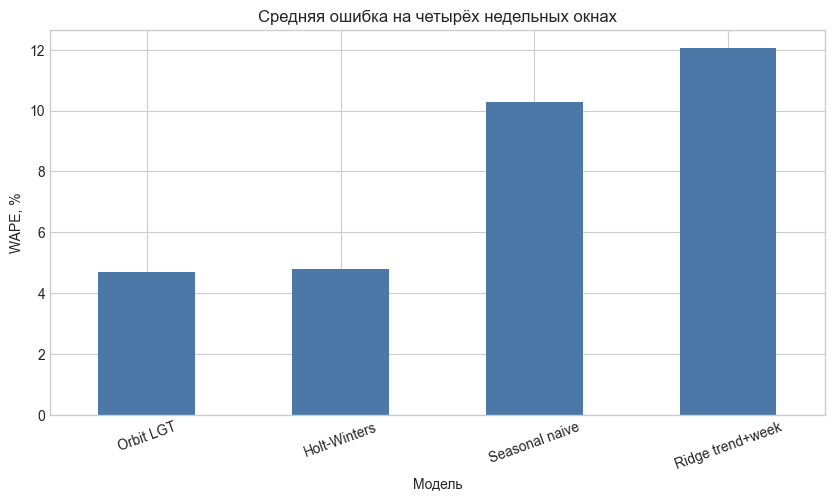

In [7]:
fig, ax = plt.subplots(figsize=(10, 5))
model_comparison["WAPE, %"].sort_values().plot.bar(ax=ax, color="#4c78a8")
ax.set(title="Средняя ошибка на четырёх недельных окнах", xlabel="Модель", ylabel="WAPE, %")
ax.tick_params(axis="x", rotation=20)
plt.show()

### Финальный прогноз на август

Модель обучается на всех 63 полных днях. Для августа индикатор флэшмоба равен нулю: новых известных маркетинговых событий в исходных данных нет.

In [8]:
future = pd.DataFrame({
    "date": pd.date_range("2026-08-01", "2026-08-31", freq="D"),
    "is_flashmob": 0,
})

final_model, forecast = orbit_forecast(daily, future, steps=301, samples=300)
forecast.head()

2026-08-01 17:40:37 - orbit - INFO - Using SVI (Pyro) with steps: 301, samples: 300, learning rate: 0.1, learning_rate_total_decay: 1.0 and particles: 100.


INFO:orbit:Using SVI (Pyro) with steps: 301, samples: 300, learning rate: 0.1, learning_rate_total_decay: 1.0 and particles: 100.


2026-08-01 17:40:37 - orbit - INFO - step    0 loss = 589.57, scale = 0.11279


INFO:orbit:step    0 loss = 589.57, scale = 0.11279


,date,prediction_5,prediction,prediction_95
0,2026-08-01,"19,190.49","20,262.48","21,292.73"
1,2026-08-02,"20,033.39","21,316.06","22,797.73"
2,2026-08-03,"19,884.40","21,732.80","23,582.03"
3,2026-08-04,"19,735.04","21,870.58","24,165.20"
4,2026-08-05,"19,574.85","22,041.66","24,803.09"


In [9]:
forecast_summary = pd.Series({
    "средний прогноз DAU": forecast["prediction"].mean(),
    "минимальный дневной прогноз": forecast["prediction"].min(),
    "максимальный дневной прогноз": forecast["prediction"].max(),
    "прогноз на 1 августа": forecast.loc[0, "prediction"],
    "прогноз на 31 августа": forecast.loc[len(forecast) - 1, "prediction"],
    "максимальная верхняя граница 95%": forecast["prediction_95"].max(),
})
forecast_summary.to_frame("значение")

,значение
средний прогноз DAU,"25,006.31"
минимальный дневной прогноз,"20,262.48"
максимальный дневной прогноз,"29,641.61"
прогноз на 1 августа,"20,262.48"
прогноз на 31 августа,"29,641.61"
максимальная верхняя граница 95%,"42,973.08"


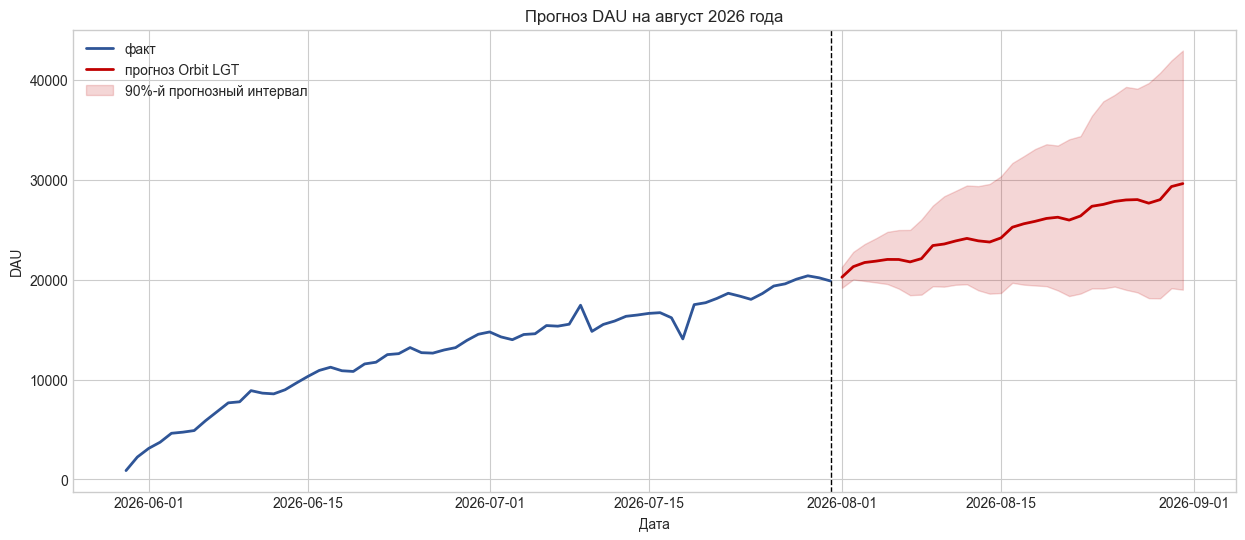

In [10]:
fig, ax = plt.subplots(figsize=(15, 6))
ax.plot(daily["date"], daily["dau"], color="#2f5597", label="факт", linewidth=2)
ax.plot(forecast["date"], forecast["prediction"], color="#c00000",
        label="прогноз Orbit LGT", linewidth=2)
ax.fill_between(
    forecast["date"], forecast["prediction_5"], forecast["prediction_95"],
    color="#c00000", alpha=0.16, label="90%-й прогнозный интервал"
)
ax.axvline(daily["date"].max(), color="black", linestyle="--", linewidth=1)
ax.set(title="Прогноз DAU на август 2026 года", xlabel="Дата", ylabel="DAU")
ax.legend()
plt.show()

## Интерпретация и ограничения

Модель продолжает наблюдавшийся рост и сохраняет недельный ритм. Точечный прогноз увеличивается примерно с 20.3 тыс. DAU 1 августа до 29.6 тыс. 31 августа; среднее за месяц — около 25 тыс. DAU в день.

Для эксплуатации разумно смотреть не только на средний прогноз, но и на верхнюю границу интервала. Однако даже она **не является готовым числом серверов**: DAU не содержит внутридневной конкуренции запросов, RPS и сложности операций.

Ключевые ограничения:

- история короткая — 63 дня, поэтому месячный горизонт не проверен несколькими rolling folds;
- первые недели содержат сильный рост; он может отражать набор аудитории или неполный старт истории и не обязан продолжаться;
- известен только один флэшмоб, поэтому его коэффициент оценивается неустойчиво;
- нет праздников, релизов, закупок трафика и инфраструктурных метрик;
- календарный день задан функцией ClickHouse `toDate(time)`; часовой пояс источника отдельно не проверялся;
- Pyro SVI даёт приближённую вероятностную оценку, а результаты могут немного меняться между версиями библиотеки.

**Практический вывод:** использовать прогноз как предварительный сценарий, еженедельно переобучать модель и отдельно связать DAU с часовыми RPS/latency перед решением о мощности.

## Бонус: насколько удобен Orbit

Для этой задачи Orbit удобен: у LGT есть тренд, сезонность, регрессоры и интервалы в одном интерфейсе, а код `fit/predict` читается просто. Главный минус — тяжёлая установка и два вычислительных backend (`Stan`/`Pyro`); для маленького учебного ряда это заметно сложнее Holt–Winters.

Сравнение по практическим признакам:

| Инструмент | Сильная сторона | Ограничение в этой задаче |
|---|---|---|
| Orbit | Байесовские state-space модели, интервалы, локальный/глобальный тренд | Тяжелее зависимости и настройка estimator |
| Prophet | Быстро задаются праздники и календарные эффекты | На 63 днях сложная сезонность всё равно слабо подтверждается |
| Darts | Единый API и backtesting для большого набора моделей | Избыточен для одного короткого ряда, больше абстракций и зависимостей |
| statsmodels | Лёгкий и прозрачный Holt–Winters | Меньше готовых вероятностных компонентов и регрессоров |

Итог: Orbit уместен, когда нужны интерпретируемые компоненты и интервалы. Для первого production-baseline я бы оставил рядом Holt–Winters: он почти не уступил по ошибке и проще в поддержке.

## Takeaways

1. DAU выбран как понятный и устойчивый индикатор активности, но для DevOps его нужно дополнить RPS и latency.
2. Данных недостаточно для надёжного месячного backtest; доступен содержательный недельный backtest.
3. Orbit LGT немного победил Holt–Winters: `WAPE ≈ 4.7%` против `≈ 4.8%`.
4. Точечный прогноз — около 25 тыс. DAU в среднем за август, но неопределённость быстро растёт.
5. Решение для эксплуатации — еженедельное переобучение, мониторинг ошибки и связывание прогноза DAU с техническими метриками нагрузки.